#### Assignment 3: Emotion Detection with CNN
    Student Name: Nujud Abdulaziz Alghamdi
    Student Number: 2300450

Step 1: Import TensorFlow and required libraries

In [245]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import os
import random
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
# Enable Kaggle API in Google Colab
import kagglehub
from tensorflow.keras.layers import Dense, Conv2D, BatchNormalization, Dropout, MaxPool2D, Flatten, MaxPooling2D
from tensorflow.keras import Sequential, layers
from keras import regularizers
from tensorflow.keras.preprocessing import image


Step 2: Define dataset path

In [246]:
# Download dataset from Kaggle
path = kagglehub.dataset_download("ananthu017/emotion-detection-fer")
print("Path to dataset files:", path)


# List all files and directories in the dataset path
dataset_files = os.listdir(path)
print("Files in dataset:", dataset_files)

train_dir = os.path.join(path, "train")
test_dir = os.path.join(path, "test")

print("Training images:", os.listdir(train_dir))
print("Test images:", os.listdir(test_dir))

Path to dataset files: /root/.cache/kagglehub/datasets/ananthu017/emotion-detection-fer/versions/1
Files in dataset: ['train', 'test']
Training images: ['disgusted', 'happy', 'angry', 'neutral', 'surprised', 'fearful', 'sad']
Test images: ['disgusted', 'happy', 'angry', 'neutral', 'surprised', 'fearful', 'sad']


In [247]:
# print classes
class_labels = sorted(os.listdir(train_dir))
num_classes = len(class_labels)

print(f"Class Labels: {class_labels}")
print(f"Number of Classes: {num_classes}")

Class Labels: ['angry', 'disgusted', 'fearful', 'happy', 'neutral', 'sad', 'surprised']
Number of Classes: 7


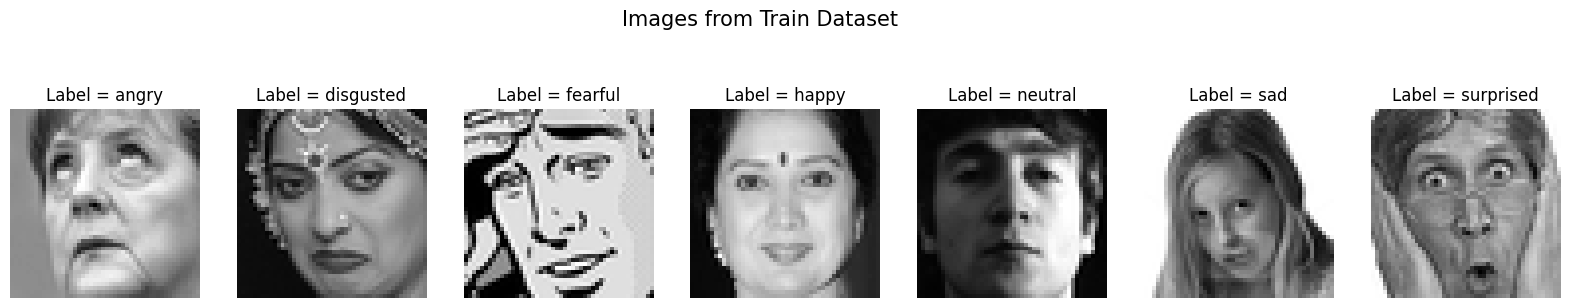

In [248]:
# Plot some images
fig, axes = plt.subplots(1, 7, figsize=(20, 4))
fig.suptitle('Images from Train Dataset', fontsize=15)
axes = axes.flatten()

for i, label in enumerate(class_labels):
    if i == len(axes):
        break

    label_path = os.path.join(train_dir, label)
    img_files = [f for f in os.listdir(label_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    if img_files:
        random_img = random.choice(img_files)
        img_path = os.path.join(label_path, random_img)
        img = mpimg.imread(img_path)

        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(f"Label = {label}")
        axes[i].axis('off')

plt.show()

Step 3: Create dataframe with file paths and labels for the dataset

In [249]:
# Verify images and labels
filepaths, labels = [], []
for fold in os.listdir(train_dir):
    foldpath = os.path.join(train_dir, fold)
    for file in os.listdir(foldpath):
        filepaths.append(os.path.join(foldpath, file))
        labels.append(fold)

train_df = pd.DataFrame({'filepaths': filepaths, 'labels': labels})

Step 4: Split the dataset into train, validation, and test sets

In [250]:
train_df, temp_df = train_test_split(train_df, test_size=0.2, random_state=42, stratify=train_df['labels'])  # 80% train, 20% temp (for validation + test)
valid_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['labels'])  # 50% of the 20% for validation, 50% for test

# Display the splits
print(f"Training data size: {len(train_df)}")
print(f"Validation data size: {len(valid_df)}")
print(f"Test data size: {len(test_df)}")

Training data size: 22967
Validation data size: 2871
Test data size: 2871


Step 5: Data Distribution Visualization (Count of each emotion)

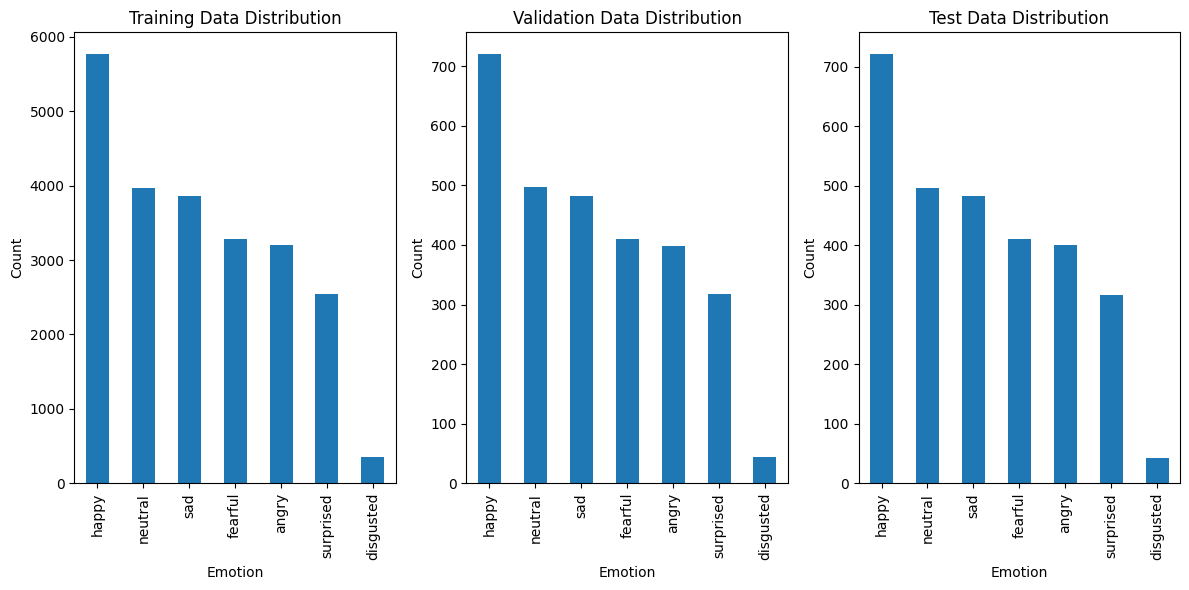

In [251]:
train_distribution = train_df['labels'].value_counts()
valid_distribution = valid_df['labels'].value_counts()
test_distribution = test_df['labels'].value_counts()

# Plot the data distribution
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
train_distribution.plot(kind='bar', title='Training Data Distribution')
plt.xlabel('Emotion')
plt.ylabel('Count')

plt.subplot(1, 3, 2)
valid_distribution.plot(kind='bar', title='Validation Data Distribution')
plt.xlabel('Emotion')
plt.ylabel('Count')

plt.subplot(1, 3, 3)
test_distribution.plot(kind='bar', title='Test Data Distribution')
plt.xlabel('Emotion')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

Step 6: Image Parameters and Augmentation

In [252]:
image_size = (48, 48)
batch_size = 64
print(f"Image size: {image_size}, Batch size: {batch_size}")

Image size: (48, 48), Batch size: 64


Step 7: Create data generators for train, and validation sets with augmentation for training

In [253]:
tr_gen = ImageDataGenerator()
ts_gen = ImageDataGenerator()

train_generator = tr_gen.flow_from_dataframe( train_df, x_col= 'filepaths', y_col= 'labels', target_size= image_size, class_mode= 'sparse',
                                    color_mode= 'grayscale', shuffle= True, batch_size= batch_size)

valid_generator = ts_gen.flow_from_dataframe( valid_df, x_col= 'filepaths', y_col= 'labels', target_size= image_size, class_mode= 'sparse',
                                    color_mode= 'grayscale', shuffle= True, batch_size= batch_size)

test_gen = ts_gen.flow_from_dataframe( test_df, x_col= 'filepaths', y_col= 'labels', target_size= image_size, class_mode= 'sparse',
                                    color_mode= 'grayscale', shuffle= False, batch_size= batch_size)

num_classes = len(train_generator.class_indices)

Found 22967 validated image filenames belonging to 7 classes.
Found 2871 validated image filenames belonging to 7 classes.
Found 2871 validated image filenames belonging to 7 classes.


Step 8: Define the CNN model

In [254]:

# Build the Model
model = Sequential([


    # First Convolutional Block:

    # Convolutional layer with 32 filters, 3x3 kernel, ReLU activation, 'same' padding to preserve spatial dimensions.
    Conv2D(32, kernel_size=(3, 3), padding='same', activation='relu', input_shape=(48, 48, 1)),
    # convolutional layer with 64 filters to extract more complex features.
    Conv2D(64, (3, 3), padding='same', activation='relu'),
    # Normalizes activations, speeding up training and reducing overfitting.
    BatchNormalization(),
    # Reduces spatial dimensions by half (downsampling).
    MaxPool2D(pool_size=(2, 2)),
    # Drops 25% of neurons to prevent overfitting.
    Dropout(0.25),


    # Second Convolutional Block:

    # Larger kernel (5x5) for wider feature extraction.
    Conv2D(128, (5, 5), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPool2D(pool_size=(2, 2)),
    Dropout(0.25),


    # Third Convolutional Block with Regularization:

    # 512 filters for deeper feature extraction with L2 regularization to prevent overfitting.
    Conv2D(512, (3, 3), padding='same', activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    BatchNormalization(),
    MaxPool2D(pool_size=(2, 2)),
    Dropout(0.25),


    # Fourth Convolutional Block:

    # 512-filter convolutional layer to learn more detailed patterns.
    Conv2D(512, (3, 3), padding='same', activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    BatchNormalization(),
    MaxPool2D(pool_size=(2, 2)),
    Dropout(0.25),


    # Fully Connected Layers:

    # Converts 2D feature maps into 1D feature vector.
    Flatten(),
    # Fully connected layer with 256 neurons.
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.25),


    # fully connected layer with 512 neurons:
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.25),


    # Output Layer:

    # Output layer with 'num_classes' neurons (one for each emotion category) and softmax activation for classification.
    Dense(num_classes, activation='softmax')

])

# Model Summary
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_24"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_100 (Conv2D)                  │ (None, 48, 48, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_101 (Conv2D)                  │ (None, 48, 48, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_119              │ (None, 48, 48, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_80 (MaxPooling2D)      │ (None, 24, 24, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_90 (Dropout)                 │ (None, 24, 24, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_102 (Conv2D)                  │ (None, 24, 24, 128)         │         204,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_120              │ (None, 24, 24, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_81 (MaxPooling2D)      │ (None, 12, 12, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_91 (Dropout)                 │ (None, 12, 12, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_103 (Conv2D)                  │ (None, 12, 12, 512)         │         590,336 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_121              │ (None, 12, 12, 512)         │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_82 (MaxPooling2D)      │ (None, 6, 6, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_92 (Dropout)                 │ (None, 6, 6, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_104 (Conv2D)                  │ (None, 6, 6, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_122              │ (None, 6, 6, 512)           │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_83 (MaxPooling2D)      │ (None, 3, 3, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_93 (Dropout)                 │ (None, 3, 3, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_22 (Flatten)                 │ (None, 4608)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_60 (Dense)                     │ (None, 256)                 │       1,179,904 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 4,496,903 (17.15 MB)

 Trainable params: 4,492,935 (17.14 MB)

 Non-trainable params: 3,968 (15.50 KB)

Step 9: Compile the model

In [255]:
# Compile the Model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
print("Model compiled successfully.")

Model compiled successfully.


Step 10: Train the model

In [256]:
history = model.fit(train_generator, epochs=20, batch_size=32, validation_data=valid_generator)

Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


359/359 ━━━━━━━━━━━━━━━━━━━━ 29s 53ms/step - accuracy: 0.2210 - loss: 7.4804 - val_accuracy: 0.2741 - val_loss: 3.0016
Epoch 2/20
359/359 ━━━━━━━━━━━━━━━━━━━━ 12s 32ms/step - accuracy: 0.3787 - loss: 2.5069 - val_accuracy: 0.3866 - val_loss: 2.2997
Epoch 3/20
359/359 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.4636 - loss: 2.2083 - val_accuracy: 0.4037 - val_loss: 2.4278
Epoch 4/20
359/359 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.4969 - loss: 2.2240 - val_accuracy: 0.3953 - val_loss: 2.3296
Epoch 5/20
359/359 ━━━━━━━━━━━━━━━━━━━━ 12s 32ms/step - accuracy: 0.5159 - loss: 2.0930 - val_accuracy: 0.4929 - val_loss: 2.2531
Epoch 6/20
359/359 ━━━━━━━━━━━━━━━━━━━━ 12s 32ms/step - accuracy: 0.5257 - loss: 2.1145 - val_accuracy: 0.3831 - val_loss: 2.9349
Epoch 7/20
359/359 ━━━━━━━━━━━━━━━━━━━━ 12s 32ms/step - accuracy: 0.5410 - loss: 2.0296 - val_accuracy: 0.4013 - val_loss: 2.4123
Epoch 8/20
359/359 ━━━━━━━━━━━━━━━━━━━━ 12s 32ms/step - accuracy: 0.5474 - loss: 2.0203 - val_accurac

Step 11: Plot training history

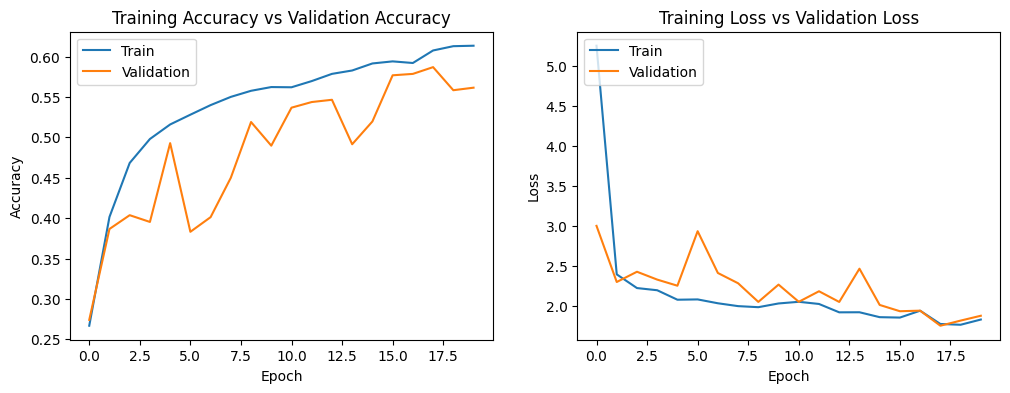

In [257]:
# Plot Training History
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(history.history['accuracy'])
ax[0].plot(history.history['val_accuracy'])
ax[0].set_title('Training Accuracy vs Validation Accuracy')
ax[0].set_ylabel('Accuracy')
ax[0].set_xlabel('Epoch')
ax[0].legend(['Train', 'Validation'], loc='upper left')

ax[1].plot(history.history['loss'])
ax[1].plot(history.history['val_loss'])
ax[1].set_title('Training Loss vs Validation Loss')
ax[1].set_ylabel('Loss')
ax[1].set_xlabel('Epoch')
ax[1].legend(['Train', 'Validation'], loc='upper left')

plt.show()

Step 12: Evaluate on test dataset

Evaluating model on test dataset...
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step


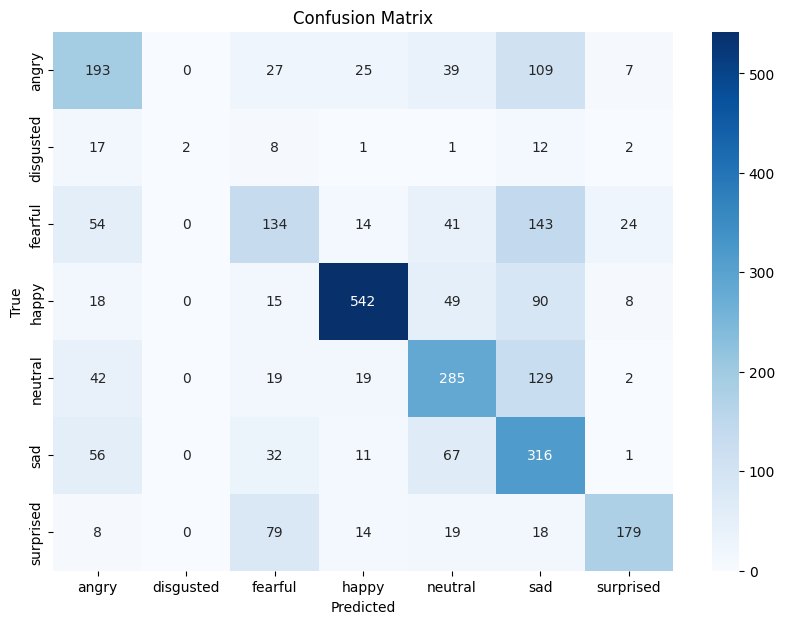

Classification Report:
              precision    recall  f1-score   support

       angry       0.50      0.48      0.49       400
   disgusted       1.00      0.05      0.09        43
     fearful       0.43      0.33      0.37       410
       happy       0.87      0.75      0.80       722
     neutral       0.57      0.57      0.57       496
         sad       0.39      0.65      0.49       483
   surprised       0.80      0.56      0.66       317

    accuracy                           0.58      2871
   macro avg       0.65      0.49      0.50      2871
weighted avg       0.61      0.58      0.58      2871



In [258]:
# Evaluate Model

print("Evaluating model on test dataset...")
y_true = test_gen.classes
y_pred = model.predict(test_gen)
y_pred = np.argmax(y_pred, axis=1)

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=test_gen.class_indices.keys(), yticklabels=test_gen.class_indices.keys())
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Print classification report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=test_gen.class_indices.keys()))


Step 13: Prediction on a Sample Image

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 541ms/step
Predicted Emotion: happy


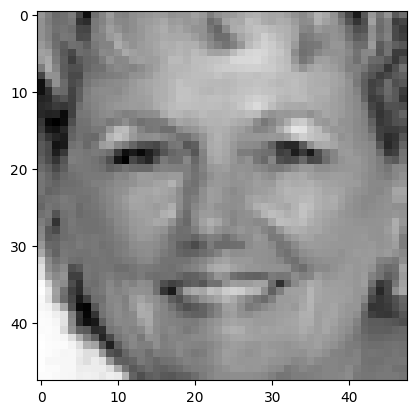

In [259]:
# Prediction on a Sample Image
label_dict = {i: class_labels[i] for i in range(num_classes)}

img_path = os.path.join(test_dir, 'happy', 'im1002.png')

img = image.load_img(img_path, target_size=(48, 48), color_mode="grayscale")
img = np.array(img)
plt.imshow(img, cmap='gray')

img = np.expand_dims(img, axis=0)
img = img.reshape(1, 48, 48, 1)

result = model.predict(img)
result = list(result[0])

img_index = result.index(max(result))
print(f"Predicted Emotion: {label_dict[img_index]}")

References

 https://www.kaggle.com/code/kirollosashraf/emotion-detection-cnn/notebook#2%7C-Data-preprocessing

https://www.kaggle.com/code/odins0n/emotion-detection/notebook#2.-HyperParameters

https://www.kaggle.com/code/kanncaa1/deep-learning-tutorial-for-beginners#Overview-the-Data-Set

https://www.comet.com/site/blog/how-to-train-your-deep-learning-models-faster/

https://stackoverflow.com/questions/69014384/input-0-of-layer-dense-is-incompatible-with-the-layer-expected-axis-1-of-input